# 7-1. 공분산

X변수가 변할 때 Y변수가 얼만큼 변하는지를 나타내는 값(+, -, 0: 독립0)  
공분산이 0이라도 독립이 아닐 수 있으며, 이는 비선형 관계가 있을 수도 있기 때문임.

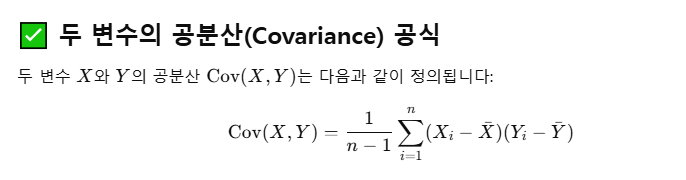


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.array([4, 6, 6, 8, 8, 9, 9, 10, 12, 12])
Y = np.array([39, 42, 45, 47, 50, 50, 52, 55, 57, 60])

cov = np.cov(X, Y)

display(pd.DataFrame(cov, index=['X', 'Y'], columns=['X', 'Y']))
print(f"X-Y 간 공분산: {cov[0, 1]:.3f}")

,X,Y
X,6.711111,16.800000
Y,16.800000,44.011111


X-Y 간 공분산: 16.800


# 7-2. 상관계수

공분산은 변수의 측정단위 영향을 받으므로 그 값 자체의 연관성이 얼마나 높은지 확인이 어려움.  
이 단점을 해결하기 위해 공분산을 각 변수의 표준편차로 나눈 상관계수 사용
- 연속형 변수: 피어슨 상관계수(선형)
- 순위형 변수: 스피어만 상관계수, 켄달 타우

| 항목         | `np.cov()`           | `np.corrcoef()`                    |
| ---------- | -------------------- | ---------------------------------- |
| 의미         | **공분산** (Covariance) | **상관계수** (Correlation Coefficient) |
| 값의 범위      | 제한 없음 (단위 있음)        | -1 \~ 1 (단위 없음, 정규화됨)              |
| 단위/스케일 민감도 | ✅ 민감함                | ❌ 스케일과 단위 무관                       |
| 해석         | 두 변수의 **공통 변화량**     | 두 변수의 **선형 관계 강도**                 |
| 함수         | `np.cov(x, y)`       | `np.corrcoef(x, y)`                |


**피어슨 상관계수:** 표본상관계수, 적률상관계수(연속형 변수 간 선형 상관관계, 정규분포 가정)  
z분포를 사용하여 모상관계수의 신뢰구간 추정, t or z분포 사용하여 모상관계수(p)가 0인지 아닌지 여부 검정(무상관 검정)  
- H0: 모상관계수가 0이다. / H1: 모상관계수가 0이 아니다.

In [18]:
from scipy.stats import pearsonr

corr1 = np.corrcoef(X, Y)[0, 1]
corr2, p = pearsonr(X, Y) #피어슨 상관계수와 유의확률 반환
print(f"corr1: {corr1:.3f} / corr2: {corr2:.3f}, p-value: {p:.3f}") # 상관계수는 통계적으로 유의

corr1: 0.978 / corr2: 0.978, p-value: 0.000


**스피어만 순위상관계수:**수치형 관측치의 분포가 극단적이거나, 서열척도일 때 변수들의 비선형 관계를 표현할 떄 사용  
확률분포에 대한 정보가 없어도 되는 비모수적 상관분석, 순위로 된 데이터 내 같은 순위가 없으면, 피어슨 상관계수와 일치

In [19]:
X = np.arange(1, 11, 1) # 표본 내 동일한 순위 없음
Y = np.array([4, 3, 5, 2, 6, 1, 10, 7, 8, 9])

from scipy.stats import spearmanr

corr3, p2 = spearmanr(X, Y)

print(f"corr3: {corr3:.3f}, p-value: {p2:.3f}") # 상관계수는 통계적으로 유의

corr3: 0.661, p-value: 0.038


In [21]:
X = np.array([10, 9, 9, 8, 8, 8]) #표본 내 동일한 순위 없음
Y = np.array([6, 7, 8, 8, 7, 6.5])

from scipy.stats import spearmanr

corr4, p3 = spearmanr(X, Y)

print(f"corr4: {corr4:.3f}, p-value: {p3:.3f}") # 상관계수는 통계적으로 유의하지 않음

corr4: -0.318, p-value: 0.539


**켄탈의 타우:** 수치형 관측치의 분포가 극단적이거나, 서열척도일 때 변수들의 비선형 관계를 표현할 떄 사용, 비모수적 방식

In [22]:
X = np.array([80, 70, 60, 50, 95, 85, 77, 55, 65]) #동일순위 x
Y = np.array([6, 3, 2, 1, 8, 9, 7, 4, 5])

from scipy.stats import kendalltau

corr5, p4 = kendalltau(X, Y)

print(f"corr5: {corr5:.3f}, p-value: {p4:.3f}") # 상관계수는 통계적으로 유의

corr5: 0.722, p-value: 0.006


In [23]:
X = np.array([10, 9, 9, 8, 8, 8]) #표본 내 동일한 순위 없음
Y = np.array([6, 7, 8, 8, 7, 6.5])

corr6, p5 = kendalltau(X, Y)

print(f"corr6: {corr6:.3f}, p-value: {p5:.3f}") # 상관계수는 통계적으로 유의x

corr6: -0.251, p-value: 0.524


**크라메르의 연관계수:** 범주형 데이터의 교차표를 통해 카이제곱 독립성 검정 효과의 크기 측정(두 범주형 변수의 연관성 정도)  
범위는 0~1이며, 0.2 이하인 경우 연관성이 약하며, 0.6 이상인 경우 연관성이 높음

In [26]:
ct = pd.DataFrame([[10, 40], [30, 20]], index=['남자', '여자'], columns=['안경 O', '안경 X'])

from scipy.stats.contingency import association

V = association(ct, method='cramer')
print(f'연관계수: {V:.3f}')

연관계수: 0.408


# 연습문제

1. 어느 고등학교에서 임의로 추출한 9명의 학생들의 수학과 영어성적이 다음과 같다.  
다음 학생들의 성적에 대한 피어슨 상관계수와 스피어만 순위상관계수를 구하고, 각 상관계수가 통계적으로 유의한지 여부를 확인하시오.  
(유의수준 5%) 또한, 해당 피어슨 상관계수의 신뢰수준 90%의 신뢰구간을 계산하시오.

| 단계 | 내용           | 수식 또는 코드 예시                                              |
| -- | ------------ | -------------------------------------------------------- |
| 1  | 귀무가설 설정      | $H_0: \rho = 0$, $H_1: \rho \ne 0$                       |
| 2  | 유의수준 설정      | $\alpha = 0.10$ (90% 신뢰수준)                               |
| 3  | 피셔의 Z 변환     | $z = \frac{1}{2} \ln\left( \frac{1 + r}{1 - r} \right)$  |
| 4  | 자유도 설정       | $df = n - 3$ (Fisher 이론 기반)                              |
| 5  | z값 기준치 계산    | $z_{\alpha/2} = \text{norm.ppf}(1 - \alpha/2)$           |
| 6  | 신뢰구간 z 하한 계산 | $z_{\text{low}} = z - \frac{z_{\alpha/2}}{\sqrt{n - 3}}$ |
| 7  | 신뢰구간 z 상한 계산 | $z_{\text{up}} = z + \frac{z_{\alpha/2}}{\sqrt{n - 3}}$  |
| 8  | 역변환 (z → r)  | $r = \frac{e^{2z} - 1}{e^{2z} + 1}$                      |
| 9  | 최종 신뢰구간      | $[r_{\text{low}}, r_{\text{up}}]$                        |


In [35]:
from scipy.stats import pearsonr, spearmanr
math = [96, 93, 63, 89, 85, 84, 66, 62, 90]
eng = [98,90, 74, 84, 69, 69, 73, 61, 98]

corr1, p1 = pearsonr(math, eng)
corr2, p2 = spearmanr(math, eng)

print(f"피어슨 상관계수: {corr1:.3f}, p-value: {p1:.3f}", "통계적으로 유의" if p1 < 0.05 else "유의하지 않음")
print(f"스피어만 상관계수: {corr2:.3f}, p-value: {p2:.3f}", "통계적으로 유의" if p2 < 0.05 else "유의하지 않음")

# 귀무:모상관계수는 0 / 대립:모상관계수는 0이 아니다.(유의)
# 피셔 Z 변환
from scipy.stats import norm

a = 0.1 # 신뢰구간
z = norm.ppf(1-a/2) #za/2

df = len(math) - 3 #자유도
a = 0.5*np.log((1+corr1)/(1-corr1)) - z/np.sqrt(df)
b = 0.5*np.log((1+corr1)/(1-corr1)) + z/np.sqrt(df)

#역변환
lower = (np.exp(2*a)-1) / (np.exp(2*a)+1)
upper = (np.exp(2*b)-1) / (np.exp(2*b)+1)

print(f"피어슨 상관계수의 신뢰수준 90% 구간: {lower:.3f} ~ {upper:.3f}")

피어슨 상관계수: 0.745, p-value: 0.021 통계적으로 유의
스피어만 상관계수: 0.815, p-value: 0.007 통계적으로 유의
피어슨 상관계수의 신뢰수준 90% 구간: 0.283 ~ 0.927


2. 두 변수 X와 Y의 표준편차는 각각 4, 5 이고, 공분산이 4인 경우, 두 변수의 상관계수를 구하시오.

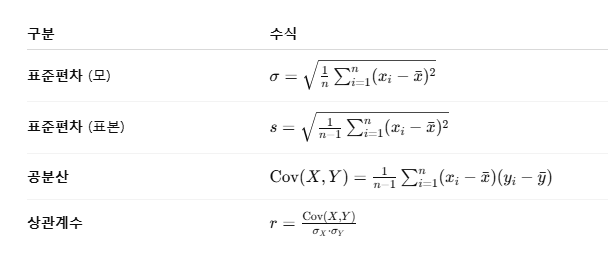

In [36]:
s1 = 4
s2 = 5
cov = 4
corr = cov/(s1*s2)

print(f"두 변수의 상관계수: {corr:.3f}")

두 변수의 상관계수: 0.200
